In [1]:
# 訓練データとテストデータの画像を読み込む
# （元画像は75×75なので、MobileNetV2が対応する縦横224pxにリサイズする）
import tensorflow as tf

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/train",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=True,
    seed=42
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/test",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=False
)

Found 300 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


In [2]:
# データの詳細を表示する
list(train_dataset.as_numpy_iterator())[0]

(array([[[[4.00000000e+01, 7.00000000e+00, 3.60000000e+01],
          [3.99799118e+01, 6.98437500e+00, 3.59754448e+01],
          [3.69665184e+01, 4.64062500e+00, 3.22924118e+01],
          ...,
          [3.14485931e+01, 1.14597473e+01, 2.81115417e+01],
          [2.10690613e+01, 7.57446289e-02, 1.80668335e+01],
          [2.10000000e+01, 0.00000000e+00, 1.80000000e+01]],
 
         [[3.99866066e+01, 6.98660707e+00, 3.59910698e+01],
          [3.99666023e+01, 6.97105694e+00, 3.59665909e+01],
          [3.69659157e+01, 4.63851738e+00, 3.22947693e+01],
          ...,
          [3.14326191e+01, 1.14386072e+01, 2.80955677e+01],
          [2.10844765e+01, 8.22570398e-02, 1.80822487e+01],
          [2.10156250e+01, 6.69640303e-03, 1.80156250e+01]],
 
         [[3.79776764e+01, 4.97767830e+00, 3.46517868e+01],
          [3.79703789e+01, 4.97333860e+00, 3.46385155e+01],
          [3.68754845e+01, 4.32238007e+00, 3.26482735e+01],
          ...,
          [2.90365849e+01, 8.26754570e+00, 2.5699

In [3]:
# 分類名（cat／dog）をリストとして格納する
class_names = train_dataset.class_names
class_names

['cat', 'dog']

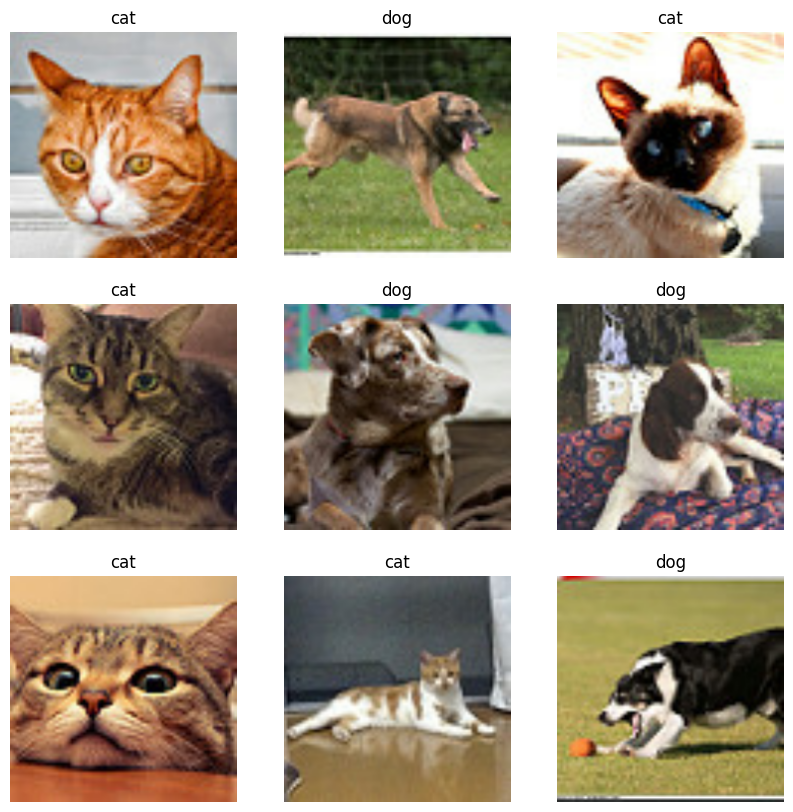

In [4]:
# 訓練データの一部を表示して確認
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])
        plt.axis("off")

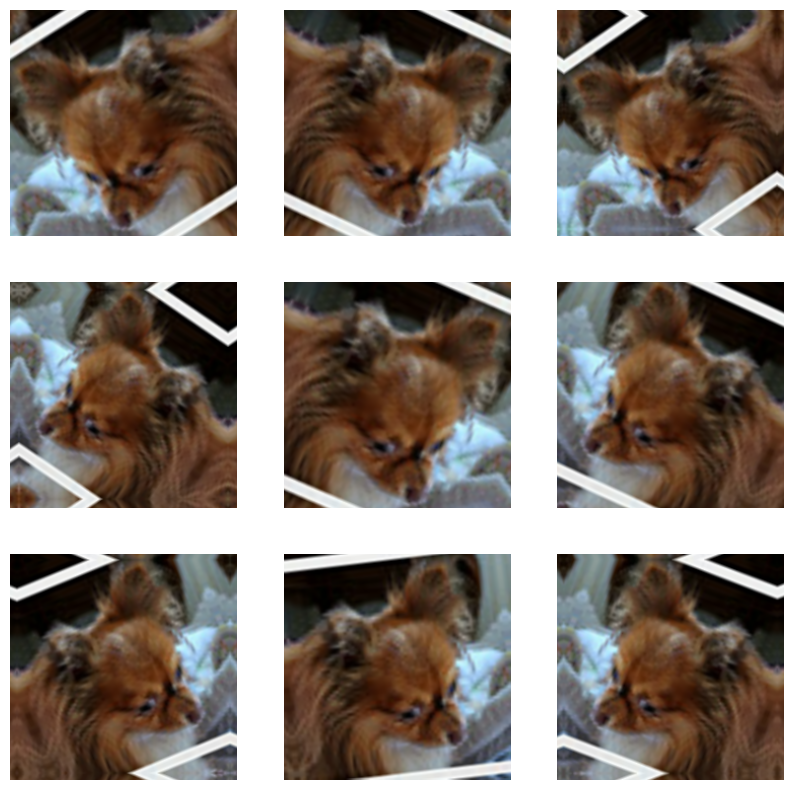

In [5]:
# データの水増しをする層を定義する（学習時のみランダムに適用される）
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),   # 左右反転
    tf.keras.layers.RandomRotation(0.1),        # ±10%（約±36度）回転
    tf.keras.layers.RandomZoom(0.1),            # ±10% 拡大・縮小
])

# 水増しした画像を表示して確認
plt.figure(figsize=(10, 10))
for images, _ in train_dataset.take(1):
    first_image = images[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented = data_augmentation(tf.expand_dims(first_image, 0), training=True)
        plt.imshow(augmented[0].numpy().astype("uint8"))
        plt.axis("off")

In [6]:
# MobileNetV2モデルを作成する
input_layer = tf.keras.Input(shape=(224, 224, 3))                  # 入力層
x = data_augmentation(input_layer)                                 # 水増しをする層
l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(x)   # 前処理（正規化：-1〜1）をする層

base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(
    input_shape=(224, 224, 3),
    input_tensor=l_layer,
    include_top=False,
    weights="imagenet",
    pooling="avg"
)
base_model.trainable = False   # 学習済みの重みは固定する（転移学習）

# 分類用の層を追加する
x = tf.keras.layers.Dropout(0.2)(base_model.output)
output_layer = tf.keras.layers.Dense(1, activation="sigmoid")(x)   # 2クラス分類なので出力は1つ（sigmoid）

model = tf.keras.Model(inputs=input_layer, outputs=output_layer)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide         │ (None, 224, 224,  │          0 │ sequential[0][0]  │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 224, 224,  │          0 │ true_divide[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ subtract[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
# モデルをコンパイルする
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [8]:
# 学習を実行する
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=test_dataset
)

Epoch 1/10


c:\Users\政岡哲太\Downloads\pythondev2\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 436ms/step - accuracy: 0.6000 - loss: 0.6861 - val_accuracy: 0.8700 - val_loss: 0.4294
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 329ms/step - accuracy: 0.9133 - loss: 0.3580 - val_accuracy: 0.9600 - val_loss: 0.2191
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 329ms/step - accuracy: 0.9567 - loss: 0.2077 - val_accuracy: 0.9900 - val_loss: 0.1383
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 333ms/step - accuracy: 0.9567 - loss: 0.1905 - val_accuracy: 0.9900 - val_loss: 0.1059
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 335ms/step - accuracy: 0.9667 - loss: 0.1308 - val_accuracy: 0.9900 - val_loss: 0.0908
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 338ms/step - accuracy: 0.9800 - loss: 0.1008 - val_accuracy: 0.9900 - val_loss: 0.0827
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 333ms/step - accuracy: 0.9633 - loss: 0.1147 - val_accuracy: 0.9900 - val_loss: 0.0750
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 338ms/step - accuracy: 0.9733 - loss: 0.0922 - val_accuracy: 0.9900 - val_

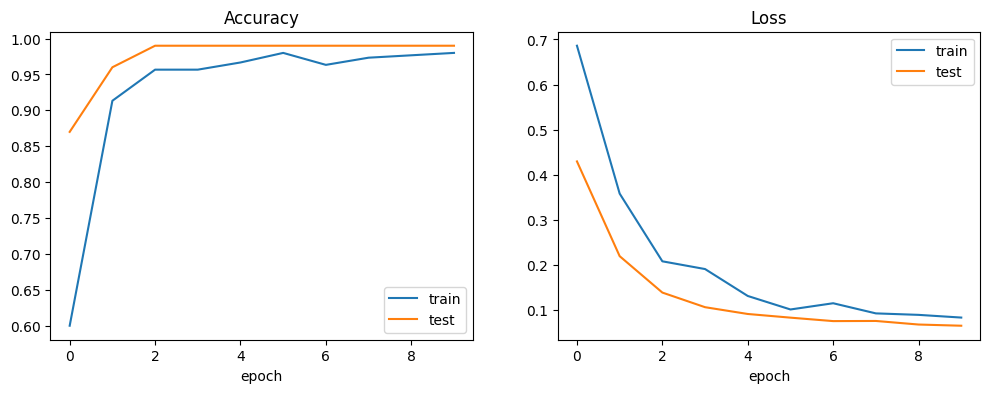

In [9]:
# 正答率と損失の推移をグラフで確認
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="test")
plt.title("Accuracy")
plt.xlabel("epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="test")
plt.title("Loss")
plt.xlabel("epoch")
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 953ms/step


c:\Users\政岡哲太\Downloads\pythondev2\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 20104 (\N{CJK UNIFIED IDEOGRAPH-4E88}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\政岡哲太\Downloads\pythondev2\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\政岡哲太\Downloads\pythondev2\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\政岡哲太\Downloads\pythondev2\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\政岡哲太\Downloads\pythondev2\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 20104 (\N{CJK UNIFIED IDEOGRAPH-4E88}) missing from font(s) DejaVu Sans.
  fig

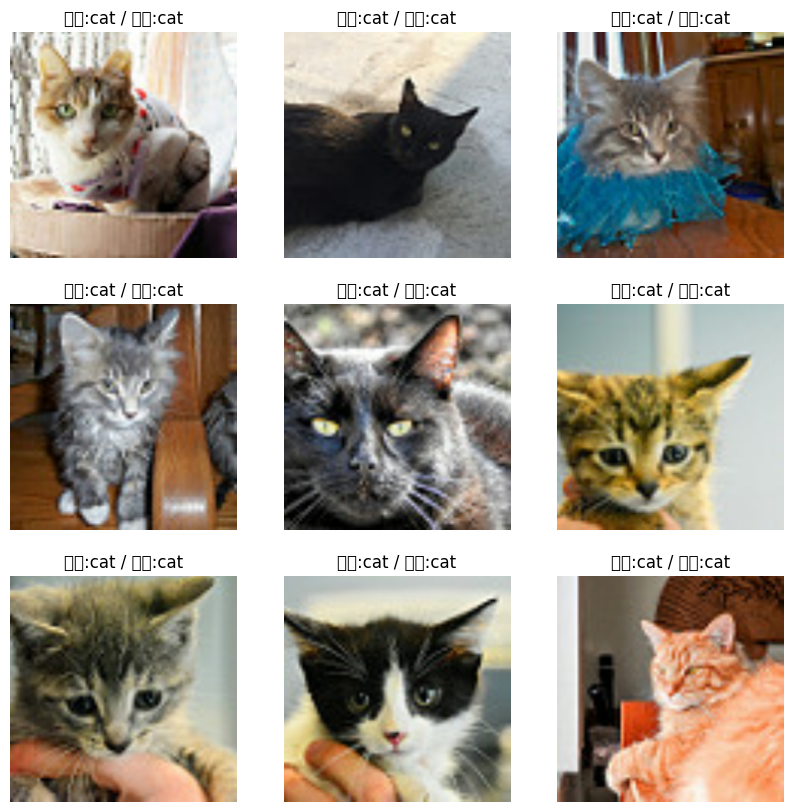

In [10]:
# テストデータの予測結果を表示して確認
plt.figure(figsize=(10, 10))
for images, labels in test_dataset.take(1):
    predictions = model.predict(images)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        pred = class_names[int(predictions[i][0] > 0.5)]
        true = class_names[int(labels[i][0])]
        plt.title(f"予測:{pred} / 正解:{true}")
        plt.axis("off")

In [11]:
# テストデータでモデルを評価し、正答率を表示する
loss, accuracy = model.evaluate(test_dataset)
print(f"テストデータの損失: {loss:.4f}")
print(f"テストデータの正答率: {accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step - accuracy: 0.9900 - loss: 0.0648
テストデータの損失: 0.0648
テストデータの正答率: 0.9900
